In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
files = {
    'sessions':   ('session_time',),
    'riders':     ('signup_date',),
    'drivers':    ('signup_date', 'last_active'),
    'trips':      ('pickup_time', 'dropoff_time'),
    'promotions': ('start_date', 'end_date'),
}
dfs = {}
for name, date_cols in files.items():
    dfs[name] = pd.read_csv(f'../ridewise project dataset/{name}.csv', parse_dates=list(date_cols))
    print(f'{name:10s}  {dfs[name].shape}')
    display(dfs[name].head())

sessions    (50000, 8)


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


riders      (10000, 8)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


drivers     (5000, 7)


,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


trips       (200000, 16)


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


promotions  (20, 11)


,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,P002,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
3,P003,Loyalty Bonus,points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
4,P004,Loyalty Bonus,points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency


In [16]:
for name, date_cols in files.items():
    for col in date_cols:
        dfs[name][col] = pd.to_datetime(dfs[name][col], errors='coerce', utc=True)

In [17]:
for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print("Null values:")
    print(df.isnull().sum())
    print("\nDuplicates:")
    print(df.duplicated().sum())
    print("\nInfo:")
    df.info()


SESSIONS
Null values:
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64

Duplicates:
0

Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   session_id      50000 non-null  str                
 1   rider_id        50000 non-null  str                
 2   session_time    50000 non-null  datetime64[us, UTC]
 3   time_on_app     50000 non-null  int64              
 4   pages_visited   50000 non-null  int64              
 5   converted       50000 non-null  int64              
 6   city            50000 non-null  str                
 7   loyalty_status  50000 non-null  str                
dtypes: datetime64[us, UTC](1), int64(3), str(4)
memory usage: 3.1 MB

RIDERS
Null values:
user_id                0

In [40]:
for name, df in dfs.items():
    print(f"\n{'=' * 80}")
    print(f"DATAFRAME: {name.upper()}")
    print(f"Shape: {df.shape}")

    print("\nNumeric summary:")
    display(df.describe())

    print("\nTop values for categorical columns:")
    cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
    for col in cat_cols:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(5))




DATAFRAME: SESSIONS
Shape: (50000, 8)

Numeric summary:


,time_on_app,pages_visited,converted
count,50000.000000,50000.000000,50000.000000
mean,97.940880,2.766360,0.156280
std,211.675749,1.554137,0.363124
min,0.000000,1.000000,0.000000
25%,12.000000,1.000000,0.000000
50%,35.000000,2.000000,0.000000
75%,90.000000,4.000000,0.000000
max,1800.000000,5.000000,1.000000



Top values for categorical columns:

session_id:
session_id
S000000    1
S000001    1
S000002    1
S000003    1
S000004    1
Name: count, dtype: int64

rider_id:
rider_id
R03390    16
R08301    16
R00790    14
R08968    14
R03955    14
Name: count, dtype: int64

session_time:
session_time
2025-04-27 17:14:41+02:05    5
2025-04-27 07:57:12+02:05    5
2025-04-27 07:49:38+00:14    5
2025-04-27 17:07:54+02:27    4
2025-04-27 07:02:27+02:27    4
Name: count, dtype: int64

city:
city
Cairo      16967
Nairobi    16598
Lagos      16435
Name: count, dtype: int64

loyalty_status:
loyalty_status
Bronze      30298
Silver      12170
Gold         5197
Platinum     2335
Name: count, dtype: int64

DATAFRAME: RIDERS
Shape: (10000, 8)

Numeric summary:


,signup_date,age,avg_rating_given,churn_prob
count,10000,10000.000000,10000.000000,10000.000000
mean,2024-04-27 00:28:48,35.154221,4.461510,0.286168
min,2023-04-27 00:00:00,18.000000,2.600000,0.002934
25%,2023-10-27 00:00:00,28.317568,4.200000,0.161691
50%,2024-04-25 00:00:00,35.037671,4.500000,0.266712
75%,2024-10-31 00:00:00,41.691186,4.800000,0.388812
max,2025-04-26 00:00:00,70.000000,5.000000,0.913302
std,NaN,9.545528,0.429162,0.159029



Top values for categorical columns:

user_id:
user_id
R00000    1
R00001    1
R00002    1
R00003    1
R00004    1
Name: count, dtype: int64

loyalty_status:
loyalty_status
Bronze      6057
Silver      2425
Gold        1050
Platinum     468
Name: count, dtype: int64

city:
city
Cairo      3374
Nairobi    3330
Lagos      3296
Name: count, dtype: int64

referred_by:
referred_by
NaN       6947
R00002      46
R00001      33
R00033      32
R00030      24
Name: count, dtype: int64

DATAFRAME: DRIVERS
Shape: (5000, 7)

Numeric summary:


...


Top values for categorical columns:

driver_id:
driver_id
D00000    1
D00001    1
D00002    1
D00003    1
D00004    1
Name: count, dtype: int64

vehicle_type:
vehicle_type
Sedan         2439
SUV           1742
Motorcycle     675
Luxury         144
Name: count, dtype: int64

city:
city
Lagos      1720
Nairobi    1709
Cairo      1571
Name: count, dtype: int64

DATAFRAME: TRIPS
Shape: (200000, 16)

Numeric summary:


,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,15.401285,1.141500,0.469566,11.849600,23.924133,11.849589,23.924173
std,6.163199,0.255362,1.100545,13.362151,14.577572,13.362229,14.577642
min,2.970000,1.000000,0.000000,-1.786360,2.879224,-1.833220,2.830979
25%,11.000000,1.000000,0.000000,-1.172683,3.496574,-1.172868,3.497195
50%,14.130000,1.000000,0.000000,6.525574,31.238814,6.525235,31.239118
75%,18.350000,1.200000,0.400000,29.934766,36.703772,29.935056,36.704067
max,82.740000,3.800000,21.860000,30.544251,37.317090,30.592457,37.364817



Top values for categorical columns:

trip_id:
trip_id
T000000    1
T000001    1
T000002    1
T000003    1
T000004    1
Name: count, dtype: int64

user_id:
user_id
R08152    42
R06728    39
R09210    38
R09908    37
R00739    37
Name: count, dtype: int64

driver_id:
driver_id
D03093    67
D01999    66
D01107    65
D02137    65
D02429    63
Name: count, dtype: int64

payment_type:
payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64

pickup_time:
pickup_time
2025-01-11 13:56:07+02:27    2
2025-01-22 08:14:50+00:14    2
2024-09-30 18:13:50+00:14    2
2024-09-29 16:31:13+02:27    2
2024-10-22 08:18:06+02:05    2
Name: count, dtype: int64

dropoff_time:
dropoff_time
2024-07-21 09:14:10+02:27    3
2024-05-21 06:35:11+00:14    2
2024-06-06 07:47:57+02:27    2
2025-01-12 08:31:19+02:27    2
2024-08-09 08:54:08+02:27    2
Name: count, dtype: int64

weather:
weather
Sunny     120151
Rainy      39976
Cloudy     29874
Foggy       9999
Name: c

,promo_value,start_date,end_date
count,20.000000,20,20
mean,26.870000,2025-04-26 00:00:00,2025-05-13 08:24:00
min,0.300000,2025-04-26 00:00:00,2025-05-03 00:00:00
25%,0.300000,2025-04-26 00:00:00,2025-05-06 00:00:00
50%,1.000000,2025-04-26 00:00:00,2025-05-14 00:00:00
75%,36.250000,2025-04-26 00:00:00,2025-05-18 06:00:00
max,100.000000,2025-04-26 00:00:00,2025-05-26 00:00:00
std,43.538115,NaN,NaN



Top values for categorical columns:

promo_id:
promo_id
P000    1
P001    1
P002    1
P003    1
P004    1
Name: count, dtype: int64

promo_name:
promo_name
First Ride Discount    8
Peak Hour Pass         5
Loyalty Bonus          5
Referral Special       2
Name: count, dtype: int64

promo_type:
promo_type
discount        8
surge_waiver    5
points          5
credit          2
Name: count, dtype: int64

target_segment:
target_segment
New       8
All       5
Gold+     5
Active    2
Name: count, dtype: int64

city_scope:
city_scope
Nairobi       6
Lagos         5
All-Cities    5
Cairo         4
Name: count, dtype: int64

ab_test_groups:
ab_test_groups
['All']                                  10
['Control', 'Variant A', 'Variant B']    10
Name: count, dtype: int64

test_allocation:
test_allocation
[1.0]              10
[0.3, 0.4, 0.3]    10
Name: count, dtype: int64

success_metric:
success_metric
ROI                10
Usage Frequency     6
Conversion Rate     4
Name: count, dtype: int64


In [26]:
dfs['sessions']['rider_id'].unique().tolist()

['R08605',
 'R08823',
 'R05342',
 'R05057',
 'R09614',
 'R01272',
 'R00576',
 'R01631',
 'R08293',
 'R07120',
 'R04300',
 'R04184',
 'R03982',
 'R06443',
 'R05266',
 'R06233',
 'R07216',
 'R08451',
 'R05262',
 'R08522',
 'R02189',
 'R07498',
 'R01257',
 'R00790',
 'R09183',
 'R00553',
 'R03069',
 'R00405',
 'R00346',
 'R08906',
 'R08348',
 'R05077',
 'R02480',
 'R01514',
 'R02683',
 'R07003',
 'R08368',
 'R01435',
 'R09310',
 'R08239',
 'R07021',
 'R07535',
 'R01871',
 'R09942',
 'R05732',
 'R00802',
 'R02595',
 'R00619',
 'R09524',
 'R06716',
 'R04647',
 'R00436',
 'R02945',
 'R05041',
 'R03323',
 'R06466',
 'R05472',
 'R07926',
 'R03455',
 'R03313',
 'R05126',
 'R08190',
 'R05831',
 'R04976',
 'R09787',
 'R09275',
 'R09984',
 'R05838',
 'R06240',
 'R06687',
 'R07442',
 'R09617',
 'R09417',
 'R00878',
 'R08790',
 'R04413',
 'R07023',
 'R01064',
 'R00218',
 'R00629',
 'R00123',
 'R01261',
 'R05469',
 'R00451',
 'R07747',
 'R01209',
 'R04457',
 'R08791',
 'R09059',
 'R05675',
 'R09349',

In [35]:
#### Cardinality of categorical columns
def count_cardinality(series):
    return series.nunique()

In [36]:
# For one column
count_cardinality(dfs['sessions']['rider_id'])

9929

In [37]:
# For all columns in one dataframe
dfs['sessions'].apply(count_cardinality)

session_id        50000
rider_id           9929
session_time      44513
time_on_app        1201
pages_visited         5
converted             2
city                  3
loyalty_status        4
dtype: int64

In [ ]:
# If you want to run it across all your dataframes:
for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print(df.apply(count_cardinality))


SESSIONS
session_id        50000
rider_id           9929
session_time      44513
time_on_app        1201
pages_visited         5
converted             2
city                  3
loyalty_status        4
dtype: int64

RIDERS
user_id             10000
signup_date           731
loyalty_status          4
age                  9553
city                    3
avg_rating_given       23
churn_prob          10000
referred_by          1660
dtype: int64

DRIVERS
driver_id          5000
rating               20
vehicle_type          4
signup_date        1090
last_active        5000
city                  3
acceptance_rate    4629
dtype: int64

TRIPS
trip_id             200000
user_id              10000
driver_id             5000
fare                  4224
surge_multiplier        27
tip                   1088
payment_type             3
pickup_time         199690
dropoff_time        199663
pickup_lat          200000
pickup_lng          200000
dropoff_lat         200000
dropoff_lng         200000
weather 

##### Outliers using IQR

In [27]:
def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

In [31]:
# for one columns
count_outliers_iqr(dfs['trips']['fare'])

np.int64(6570)

In [32]:
# For all numeric columns in one dataframe:
dfs['trips'].select_dtypes('number').apply(count_outliers_iqr)

fare                 6570
surge_multiplier    18023
tip                 31462
pickup_lat              0
pickup_lng              0
dropoff_lat             0
dropoff_lng             0
dtype: int64

In [34]:
# If you want to run it across all your dataframes:
for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print(df.select_dtypes('number').apply(count_outliers_iqr))


SESSIONS
time_on_app      5264
pages_visited       0
converted        7814
dtype: int64

RIDERS
age                 40
avg_rating_given    76
churn_prob          68
dtype: int64

DRIVERS
rating              0
acceptance_rate    13
dtype: int64

TRIPS
fare                 6570
surge_multiplier    18023
tip                 31462
pickup_lat              0
pickup_lng              0
dropoff_lat             0
dropoff_lng             0
dtype: int64

PROMOTIONS
promo_value    5
dtype: int64


###### Most of the high outlier counts (`tip`, `surge_multiplier`, `converted`) aren't dirty data — they come from zero-inflated or binary columns where IQR naturally over-flags, so they're skew, not errors. The data is broadly clean (locations and `drivers` show zero/near-zero outliers), and the only real action is verifying that `fare` and `age` contain no *impossible* values (negatives, absurd ages) before keeping the rest as genuine signal. Separately, watch `churn_prob` in `riders` — it's not an outlier issue, but a pre-existing churn column risks leakage if it enters your model.

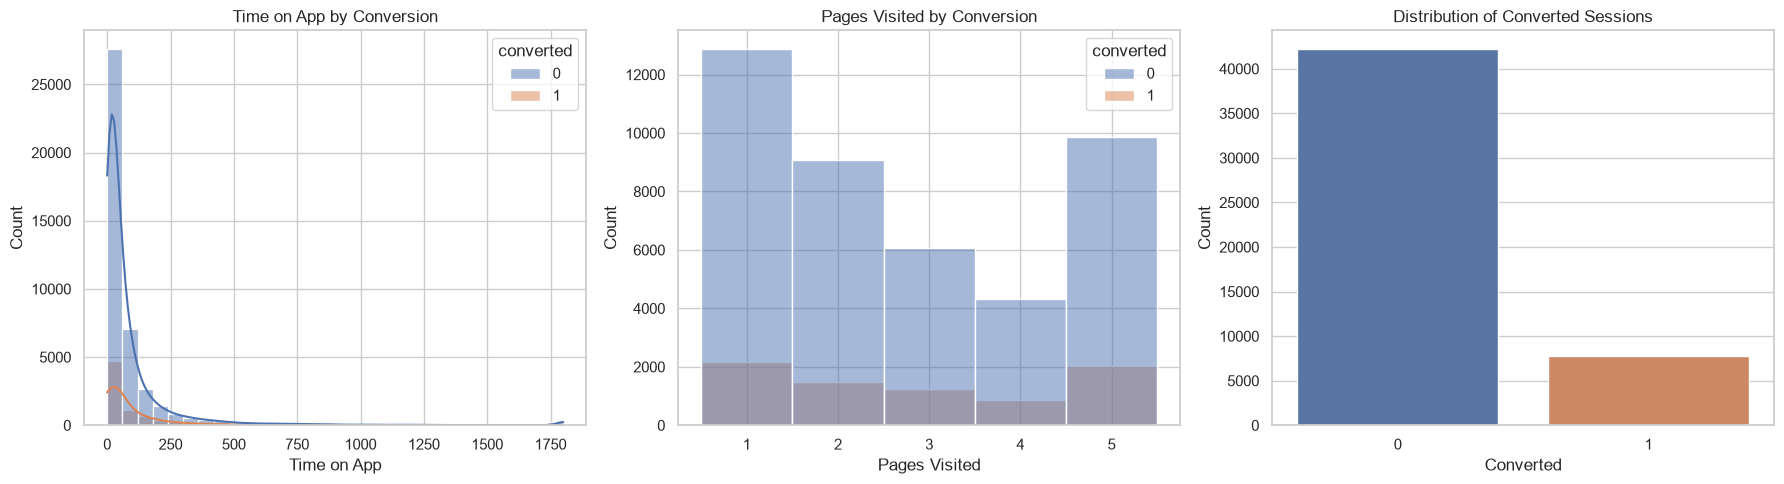

In [78]:
sns.set_theme(style="whitegrid")

sessions = dfs['sessions']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Time on App — continuous, KDE + split by converted
sns.histplot(data=sessions, x='time_on_app', hue='converted',
             bins=30, kde=True, ax=axes[0])
axes[0].set_title('Time on App by Conversion')
axes[0].set_xlabel('Time on App')
axes[0].set_ylabel('Count')

# 2. Pages Visited — discrete, split by converted (no KDE)
sns.histplot(data=sessions, x='pages_visited', hue='converted',
             discrete=True, ax=axes[1])
axes[1].set_title('Pages Visited by Conversion')
axes[1].set_xlabel('Pages Visited')
axes[1].set_ylabel('Count')

# 3. Converted — the grouping variable itself, so just count it
sns.countplot(data=sessions, x='converted', hue='converted',
              legend=False, ax=axes[2])
axes[2].set_title('Distribution of Converted Sessions')
axes[2].set_xlabel('Converted')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

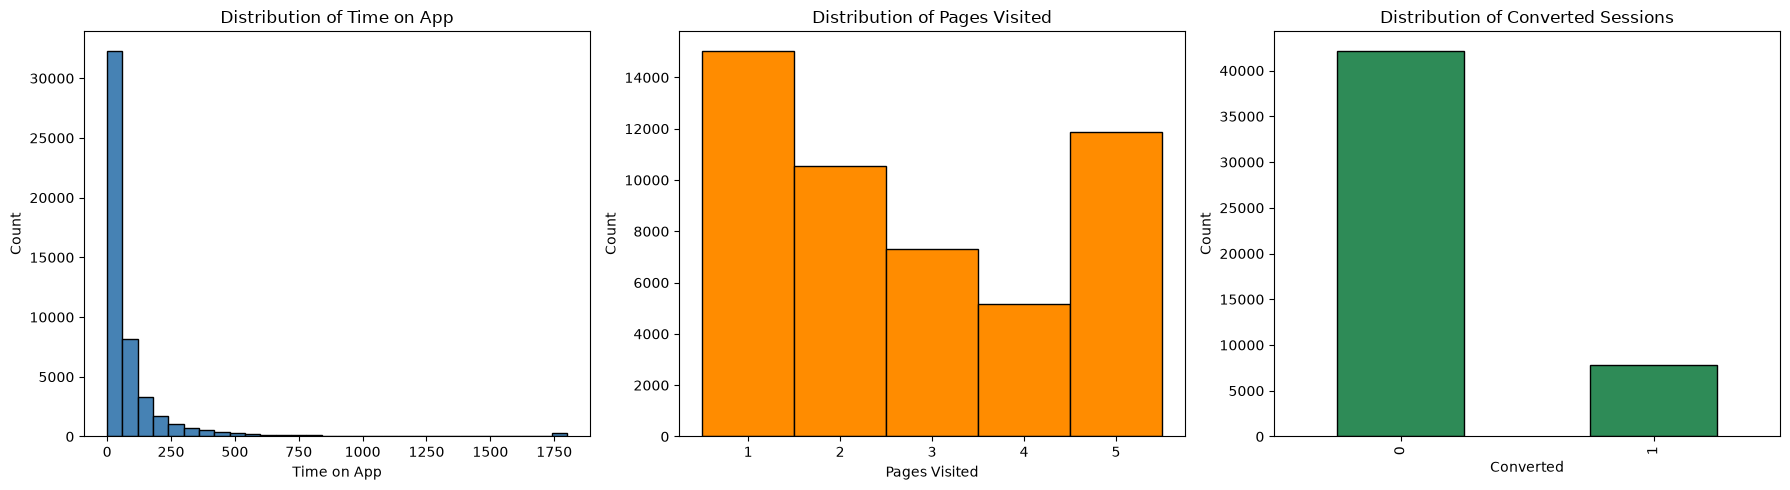

In [44]:
sessions = dfs['sessions']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sessions['time_on_app'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Time on App')
axes[0].set_xlabel('Time on App')
axes[0].set_ylabel('Count')

axes[1].hist(sessions['pages_visited'], bins=range(1, sessions['pages_visited'].max() + 2), color='darkorange', edgecolor='black', align='left')
axes[1].set_title('Distribution of Pages Visited')
axes[1].set_xlabel('Pages Visited')
axes[1].set_ylabel('Count')

sessions['converted'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Distribution of Converted Sessions')
axes[2].set_xlabel('Converted')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

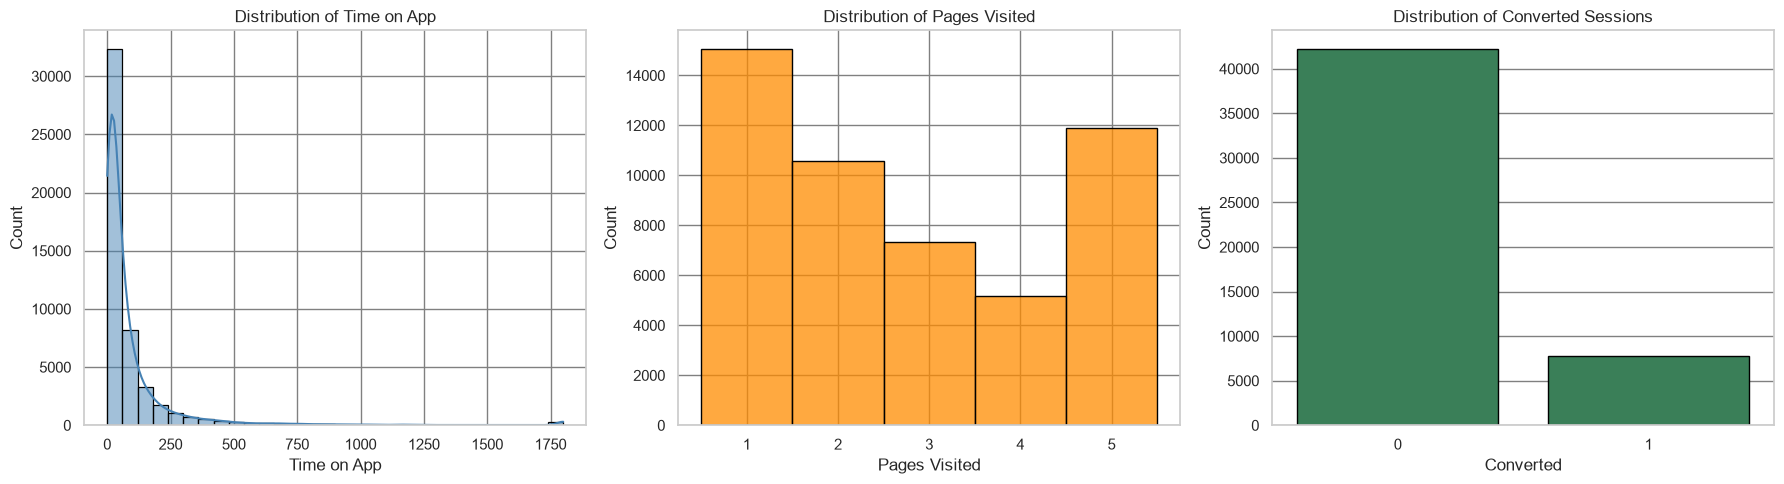

In [85]:

sns.set_theme(style="whitegrid", rc={"grid.color": "grey", "figure.facecolor": "white"})

sessions = dfs['sessions']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=sessions, x='time_on_app', bins=30, kde=True,
             color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Time on App')
axes[0].set_xlabel('Time on App')
axes[0].set_ylabel('Count')

sns.histplot(data=sessions, x='pages_visited', discrete=True,
             color='darkorange', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of Pages Visited')
axes[1].set_xlabel('Pages Visited')
axes[1].set_ylabel('Count')

sns.countplot(data=sessions, x='converted', color='seagreen',
              edgecolor='black', ax=axes[2])
axes[2].set_title('Distribution of Converted Sessions')
axes[2].set_xlabel('Converted')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

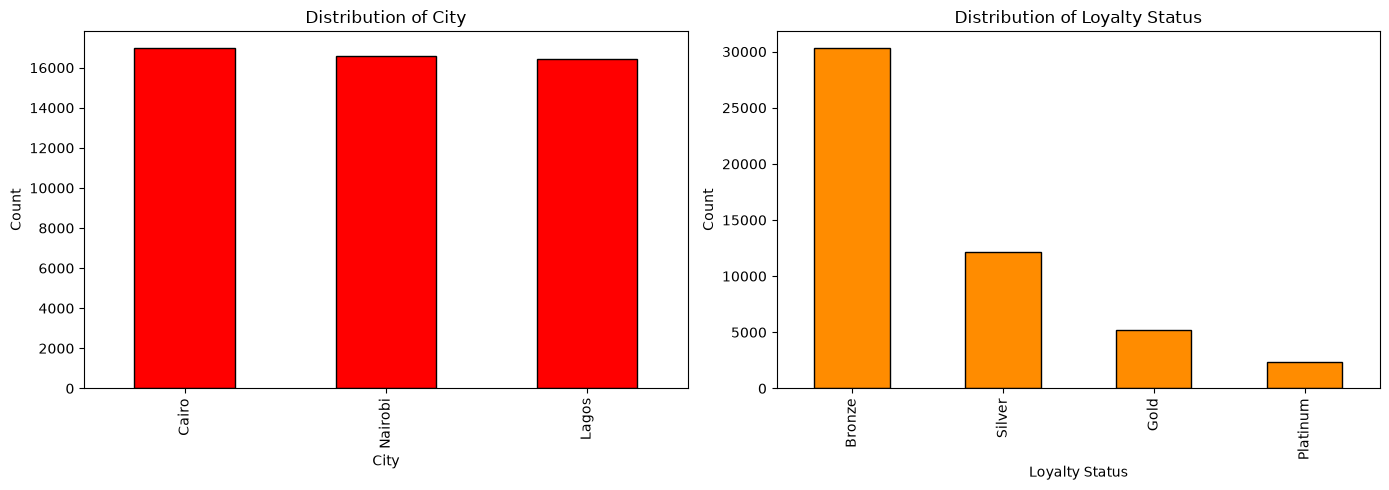

In [47]:
sessions = dfs['sessions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sessions['city'].value_counts().plot(kind='bar', ax=axes[0], color='red', edgecolor='black')
axes[0].set_title('Distribution of City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')

sessions['loyalty_status'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Loyalty Status')
axes[1].set_xlabel('Loyalty Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

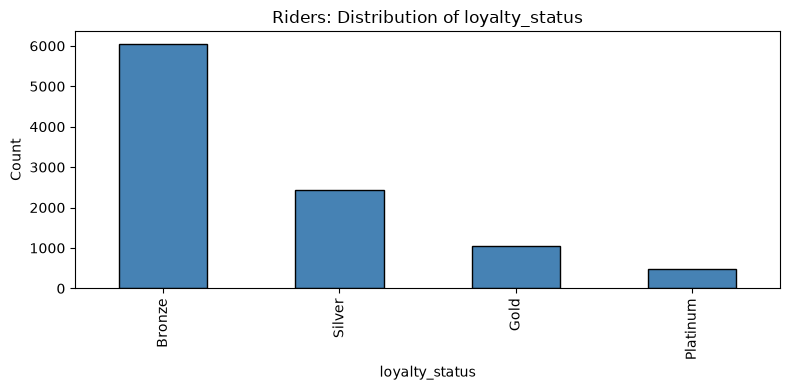

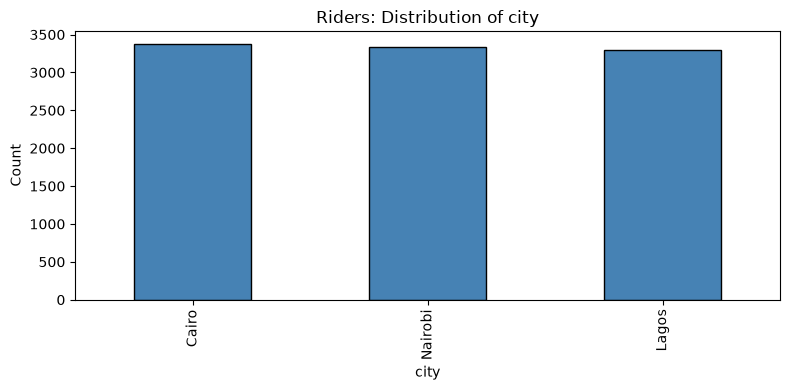

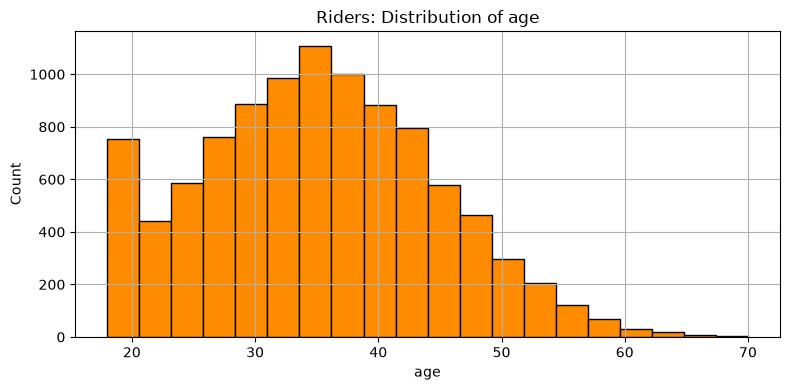

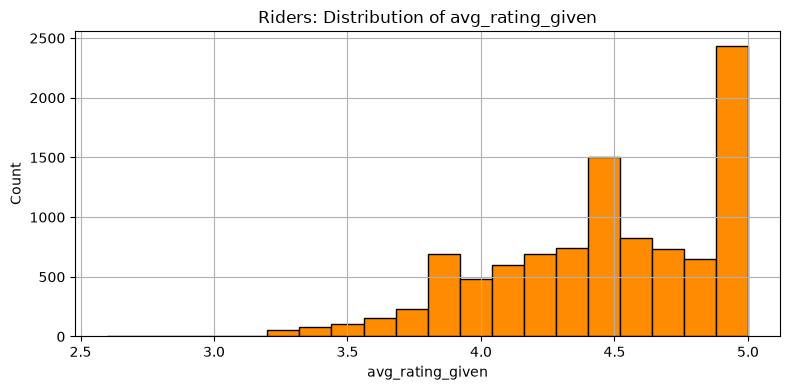

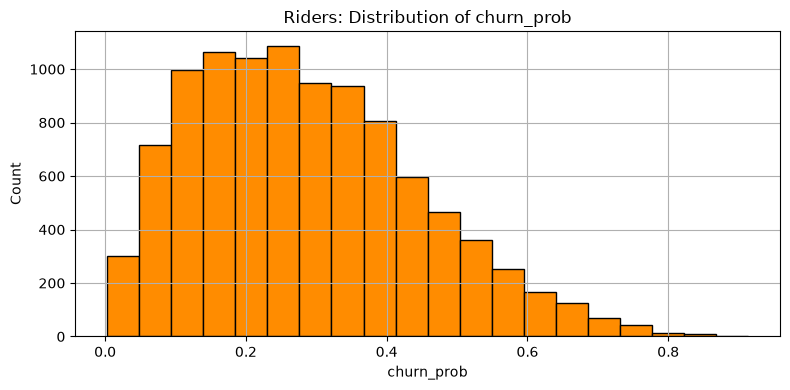

In [ ]:
# Riders
riders = dfs['riders']

cat_cols = ['loyalty_status', 'city']
num_cols = ['age', 'avg_rating_given', 'churn_prob']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    riders[col].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Riders: Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for col in num_cols:
    plt.figure(figsize=(8, 4))
    riders[col].hist(bins=20, edgecolor='black', color='darkorange')
    plt.title(f'Riders: Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

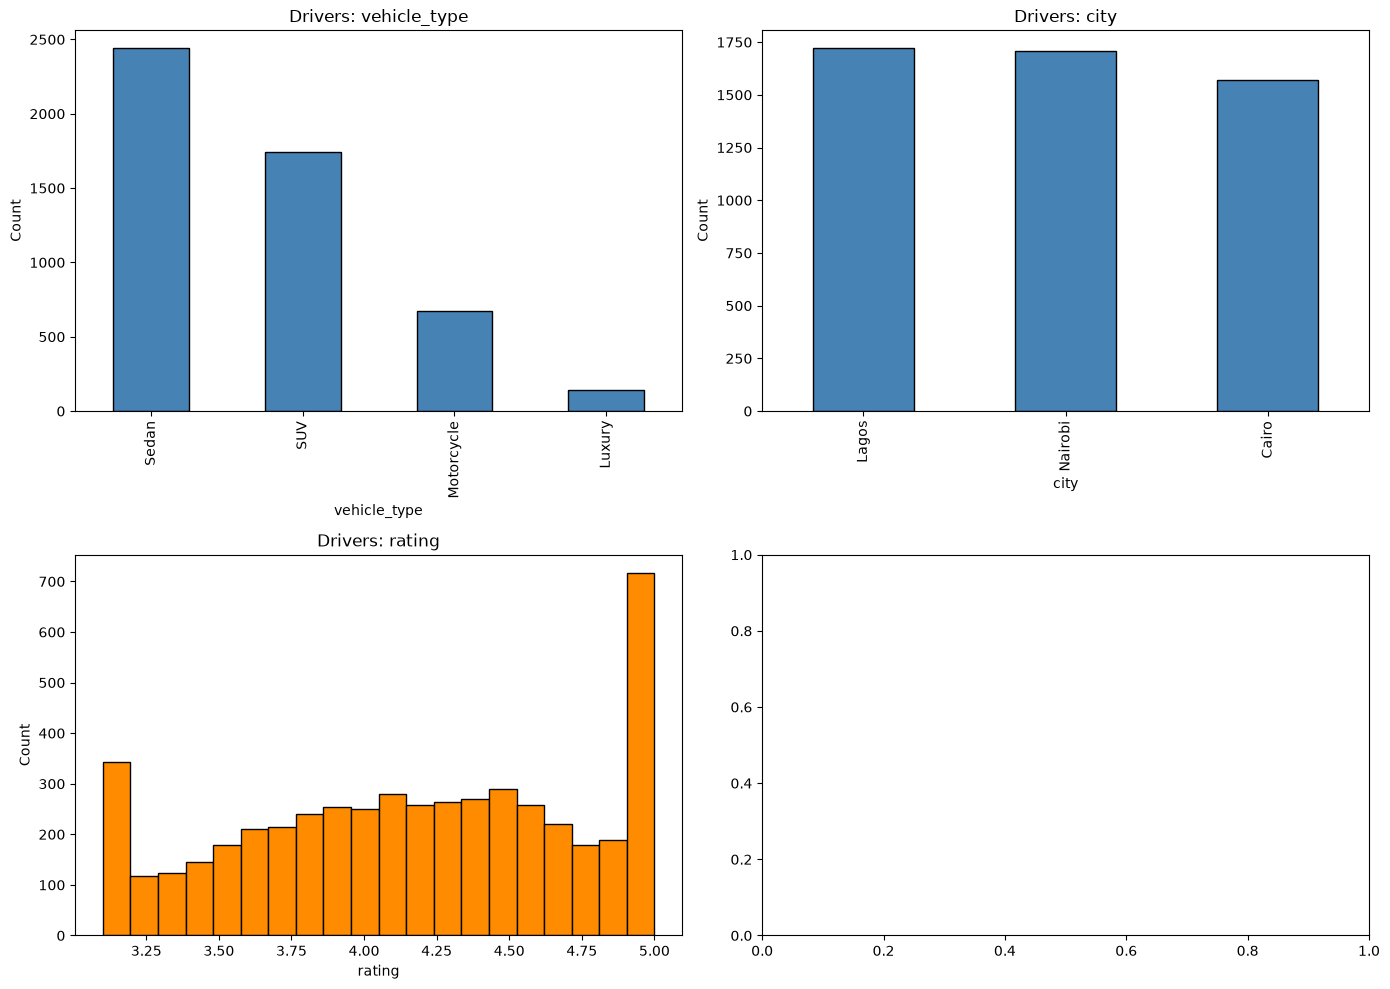

In [ ]:
# Drivers subplot + loops
drivers = dfs['drivers']
cat_cols = ['vehicle_type', 'city']
num_cols = ['rating']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    drivers[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Drivers: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for i, col in enumerate(num_cols, start=len(cat_cols)):
    axes[i].hist(drivers[col], bins=20, edgecolor='black', color='darkorange')
    axes[i].set_title(f'Drivers: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

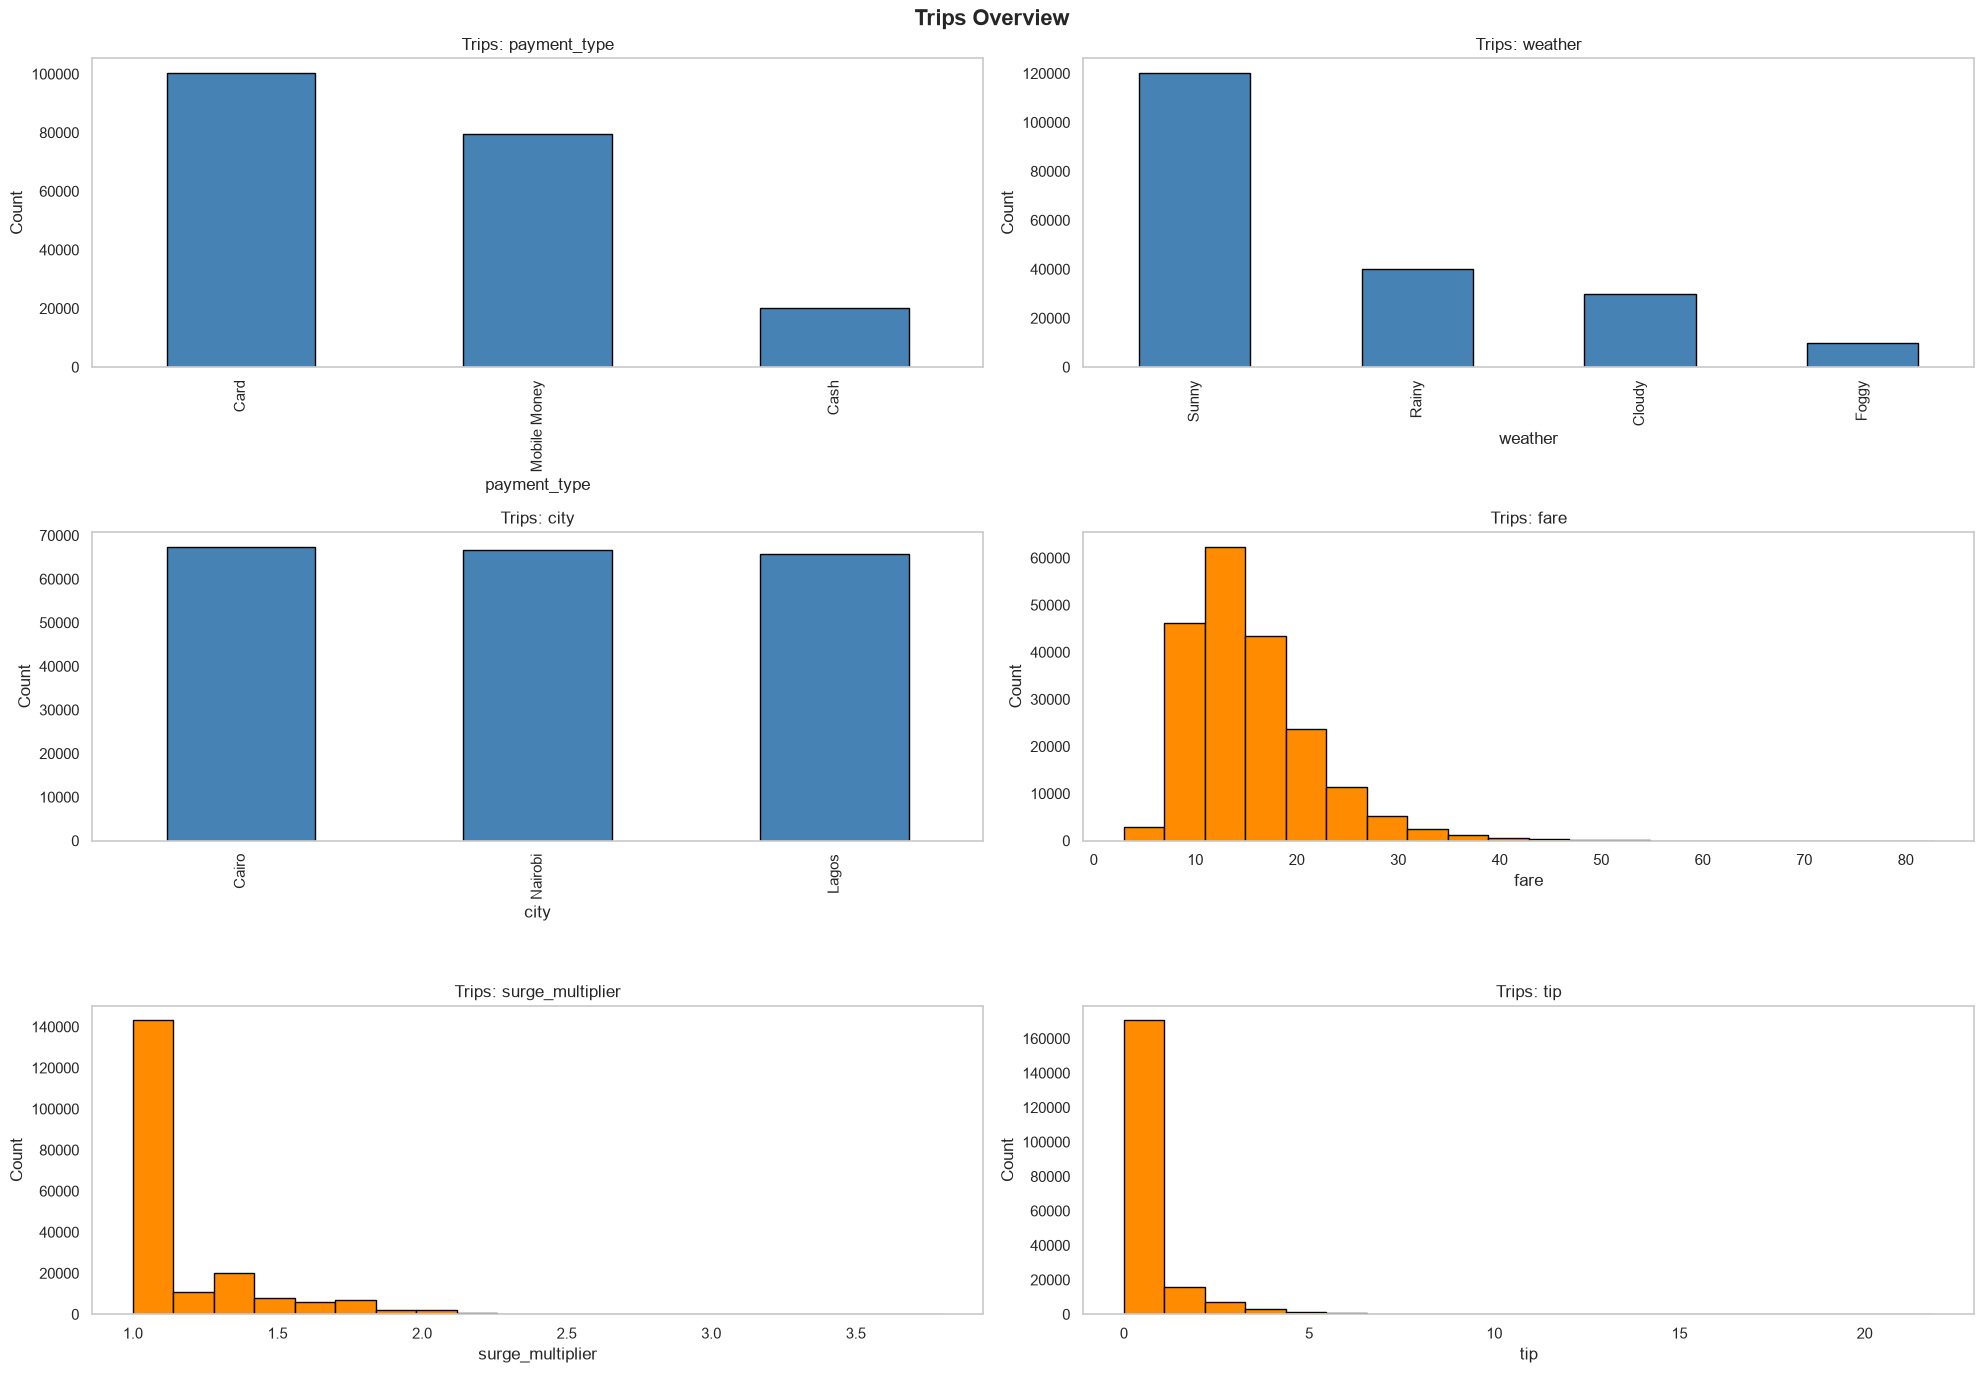

In [88]:
# Trips
trips = dfs['trips']
cat_cols = ['payment_type', 'weather', 'city']
num_cols = ['fare', 'surge_multiplier', 'tip']

fig, axes = plt.subplots(3, 2, figsize=(20, 14))
fig.suptitle('Trips Overview', fontsize=16, fontweight='bold')
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    trips[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Trips: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].grid(False)

for i, col in enumerate(num_cols, start=len(cat_cols)):
    axes[i].hist(trips[col], bins=20, edgecolor='black', color='darkorange')
    axes[i].set_title(f'Trips: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

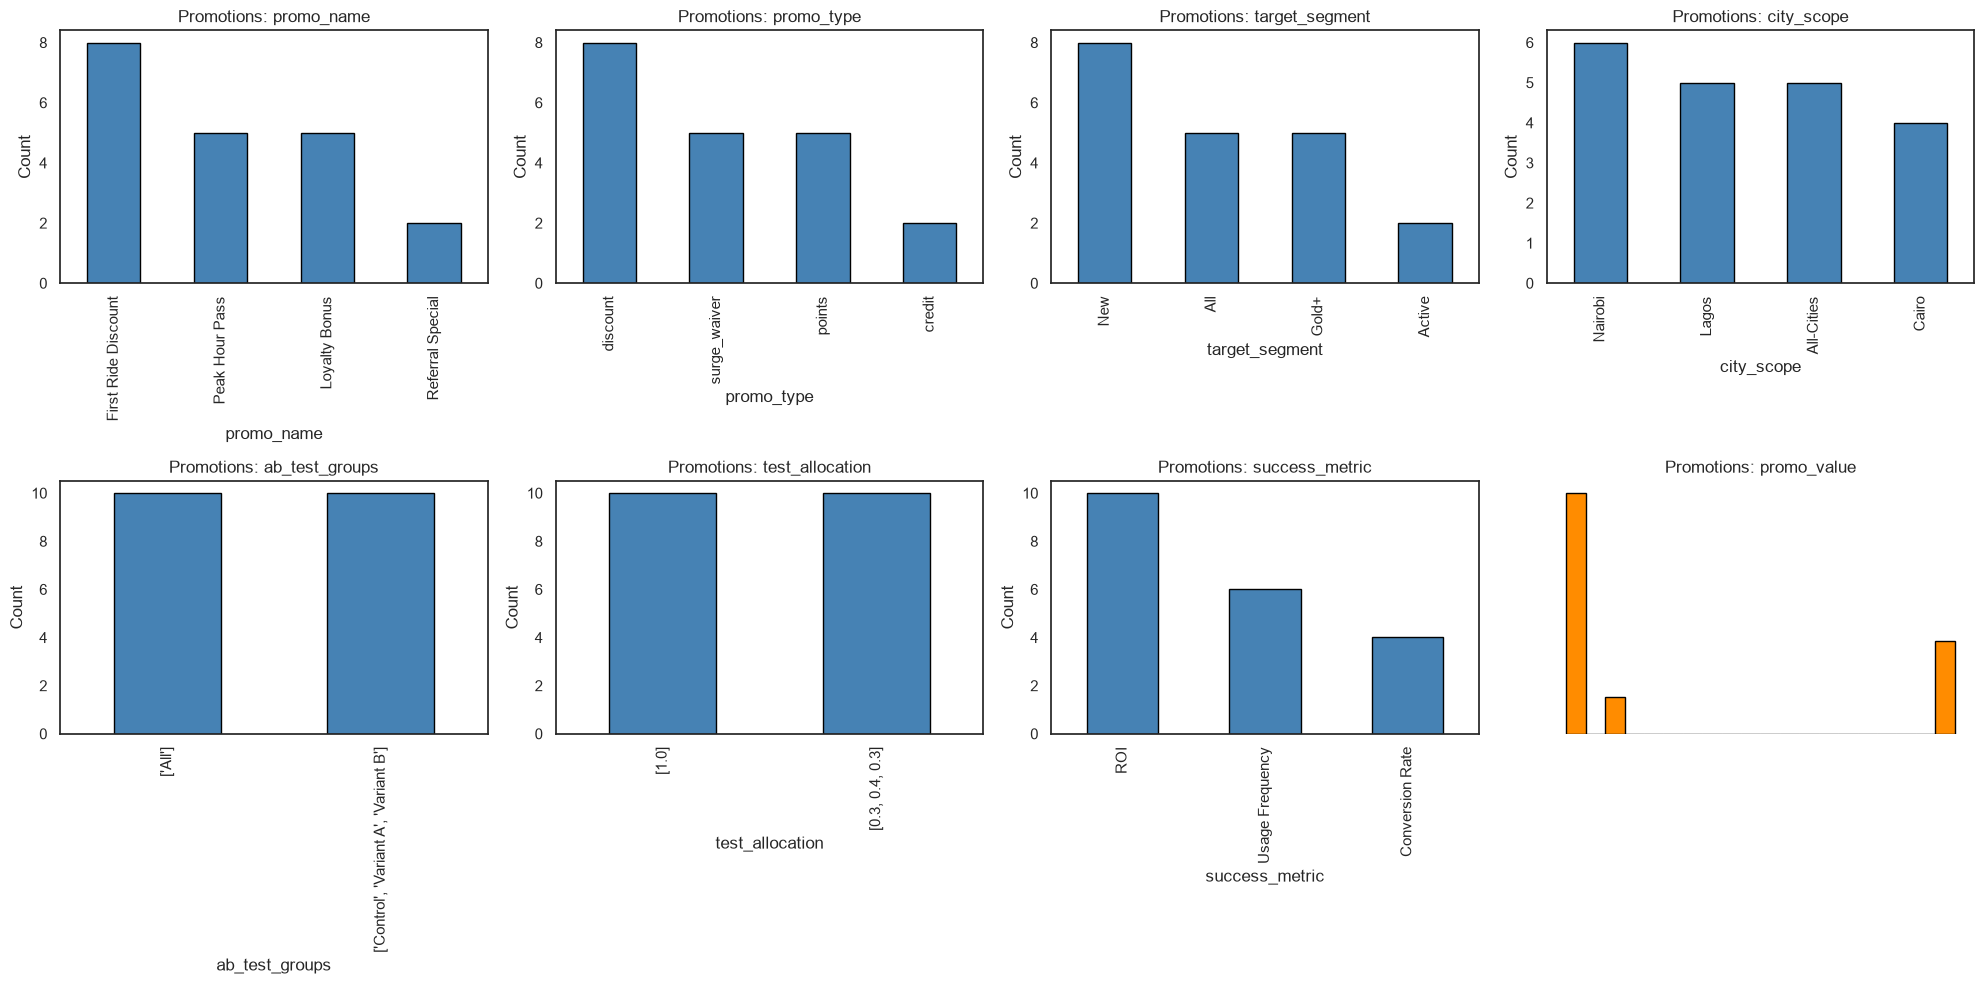

In [96]:
# Promotions
promotions = dfs['promotions']
cat_cols = ['promo_name', 'promo_type', 'target_segment', 'city_scope', 'ab_test_groups', 'test_allocation', 'success_metric']
num_cols = ['promo_value']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    promotions[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Promotions: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for i, col in enumerate(num_cols, start=len(cat_cols)):
    axes[i].hist(promotions[col], bins=20, edgecolor='black', color='darkorange')
    axes[i].set_title(f'Promotions: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[7].axis('off')

plt.tight_layout()
plt.show()

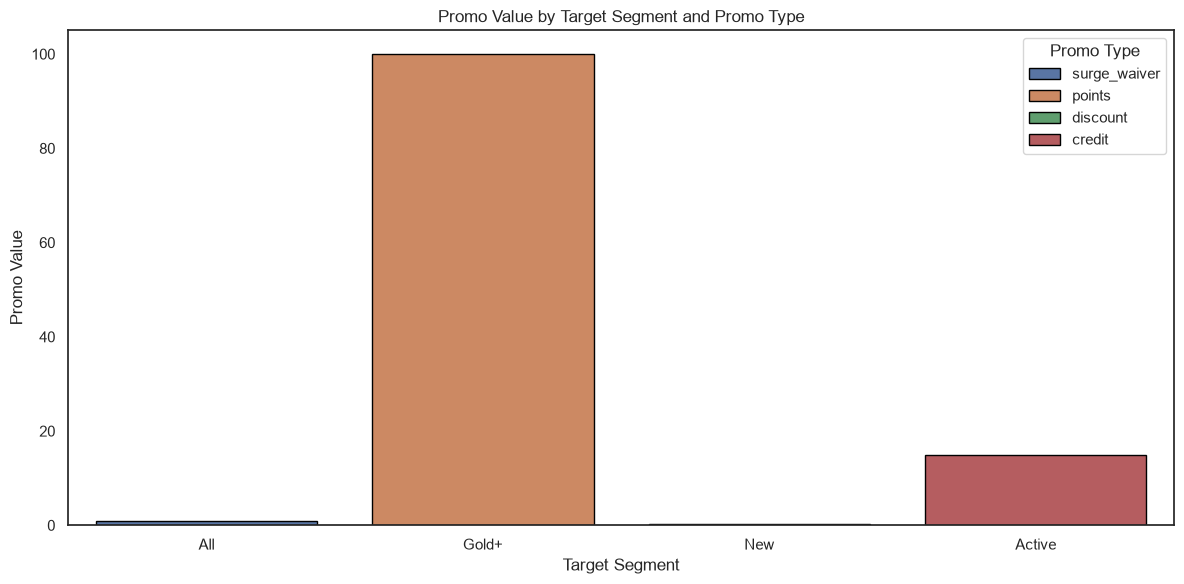

In [93]:
import seaborn as sns
sns.set_theme(style="white")

promotions = dfs['promotions']

plt.figure(figsize=(12, 6))

# promo_value on y, grouped by target_segment, colored by success_metric
sns.barplot(
    data=promotions,
    x='target_segment',
    y='promo_value',
    hue= 'promo_type',
    edgecolor='black'
)

plt.title('Promo Value by Target Segment and Promo Type')
plt.xlabel('Target Segment')
plt.ylabel('Promo Value')
plt.legend(title='Promo Type')
plt.grid(False)
plt.tight_layout()
plt.show()

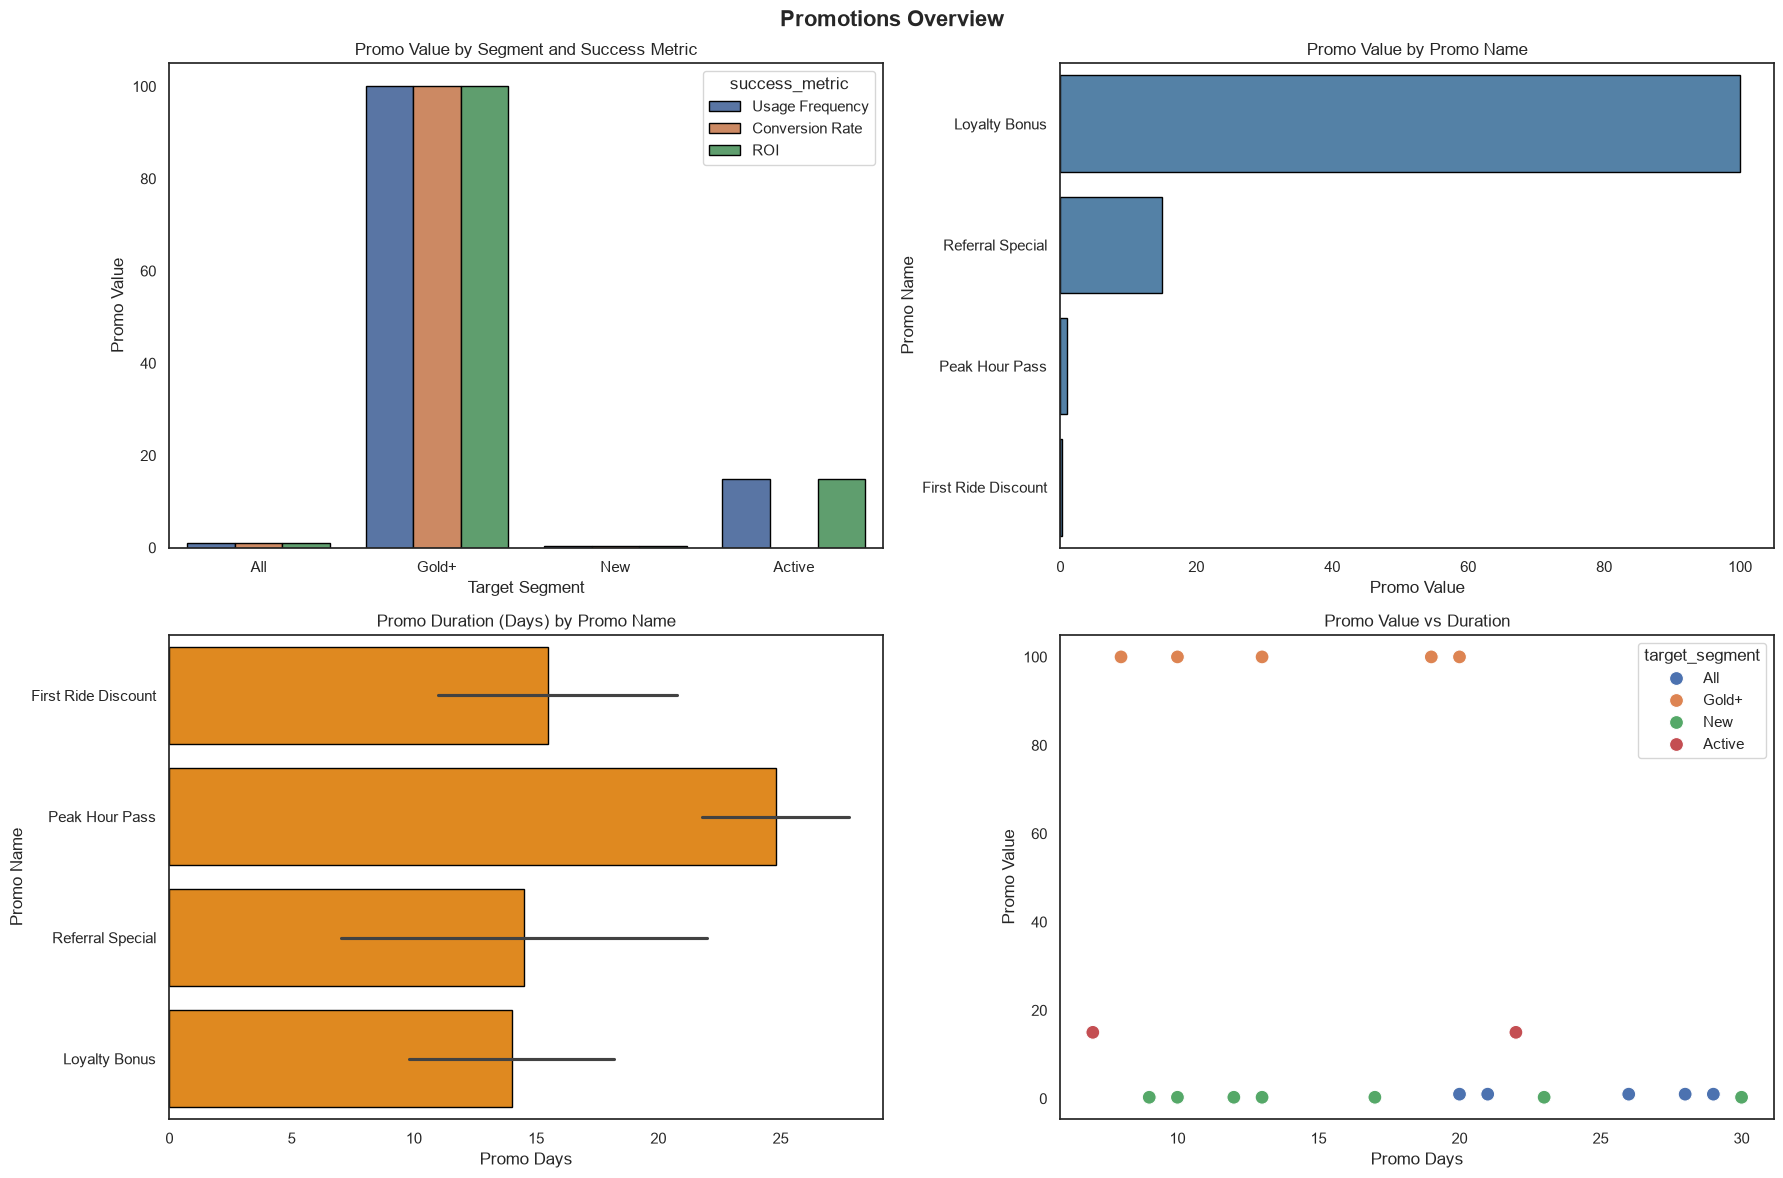

In [94]:
sns.set_theme(style="white")

promotions = dfs['promotions'].copy()

# Derive promo duration in days (since there's no promo_days column)
promotions['promo_days'] = (promotions['end_date'] - promotions['start_date']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Promotions Overview', fontsize=16, fontweight='bold')

# 1. Promo value by target segment + success metric (grouped bars)
sns.barplot(data=promotions, x='target_segment', y='promo_value',
            hue='success_metric', edgecolor='black', ax=axes[0, 0])
axes[0, 0].set_title('Promo Value by Segment and Success Metric')
axes[0, 0].set_xlabel('Target Segment')
axes[0, 0].set_ylabel('Promo Value')
axes[0, 0].grid(False)

# 2. Promo value by promo name (sorted high → low)
order = promotions.sort_values('promo_value', ascending=False)['promo_name']
sns.barplot(data=promotions, x='promo_value', y='promo_name',
            order=order, color='steelblue', edgecolor='black', ax=axes[0, 1])
axes[0, 1].set_title('Promo Value by Promo Name')
axes[0, 1].set_xlabel('Promo Value')
axes[0, 1].set_ylabel('Promo Name')
axes[0, 1].grid(False)

# 3. Promo days (duration) by promo name (sorted high → low)
order_days = promotions.sort_values('promo_days', ascending=False)['promo_name']
sns.barplot(data=promotions, x='promo_days', y='promo_name',
            order=order_days, color='darkorange', edgecolor='black', ax=axes[1, 0])
axes[1, 0].set_title('Promo Duration (Days) by Promo Name')
axes[1, 0].set_xlabel('Promo Days')
axes[1, 0].set_ylabel('Promo Name')
axes[1, 0].grid(False)

# 4. Relationship: promo value vs promo days
sns.scatterplot(data=promotions, x='promo_days', y='promo_value',
                hue='target_segment', s=100, ax=axes[1, 1])
axes[1, 1].set_title('Promo Value vs Duration')
axes[1, 1].set_xlabel('Promo Days')
axes[1, 1].set_ylabel('Promo Value')
axes[1, 1].grid(False)

plt.tight_layout()
plt.show()

hour
0      861
1      921
2     1024
3     2040
4     2842
5     3521
6     3235
7     2862
8     2282
9     2034
10    1973
11    2167
12    1878
13    2131
14    2385
15    3094
16    3423
17    3003
18    2477
19    1712
20    1176
21     953
22    1230
23     776
Name: count, dtype: int64


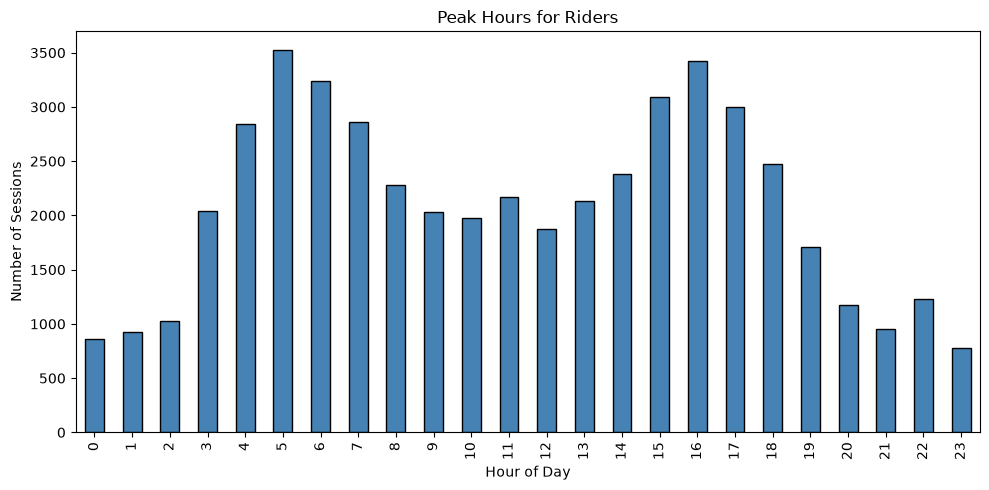

In [61]:
sessions = dfs['sessions'].copy()
sessions['session_time'] = pd.to_datetime(sessions['session_time'], errors='coerce', utc=True)
sessions['hour'] = sessions['session_time'].dt.hour
peak_hours = sessions['hour'].value_counts().sort_index()

print(peak_hours)

plt.figure(figsize=(10, 5))
peak_hours.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Peak Hours for Riders')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.tight_layout()
plt.show()

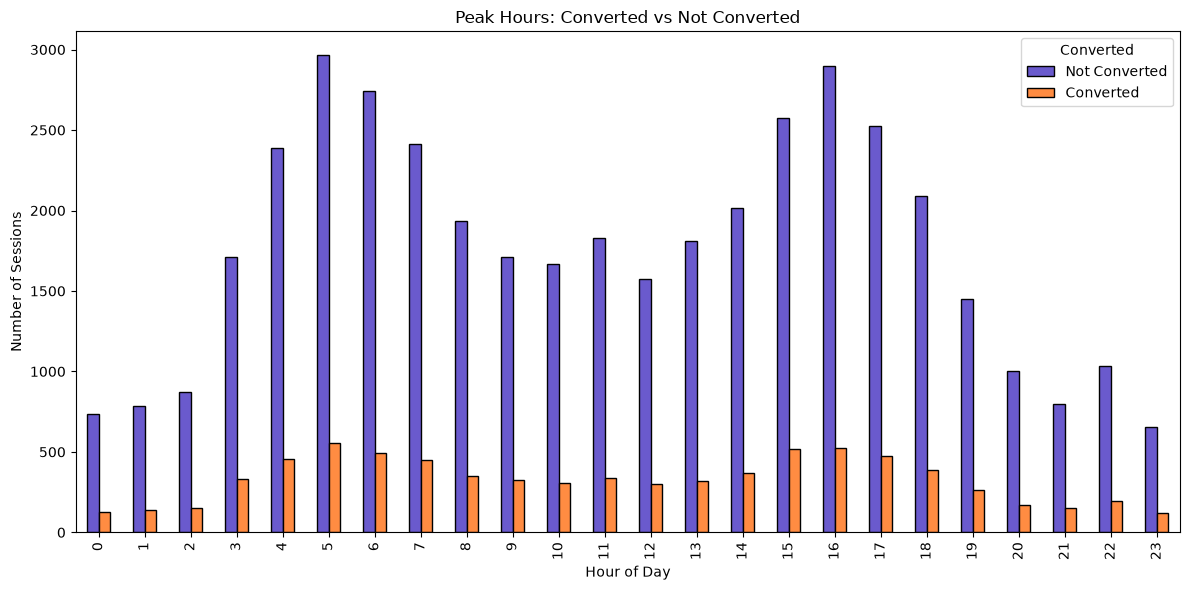

In [62]:
sessions = dfs['sessions'].copy()
sessions['session_time'] = pd.to_datetime(sessions['session_time'], errors='coerce', utc=True)
sessions['hour'] = sessions['session_time'].dt.hour

converted_hours = sessions.groupby(['hour', 'converted']).size().unstack(fill_value=0)

converted_hours.plot(kind='bar', figsize=(12, 6), edgecolor='black', color=['#6A5ACD', '#FF8C42'])
plt.title('Peak Hours: Converted vs Not Converted')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.legend(title='Converted', labels=['Not Converted', 'Converted'])
plt.tight_layout()
plt.show()

In [66]:
sessions = dfs['sessions'].copy()
sessions['session_time'] = pd.to_datetime(sessions['session_time'], errors='coerce', utc=True)
sessions['hour'] = sessions['session_time'].dt.hour

city_by_hour = (
    sessions[sessions['converted'] == 1]
    .groupby(['hour', 'city'])
    .size()
    .reset_index(name='converted_count')
)

top_city_by_hour = city_by_hour.loc[
    city_by_hour.groupby('hour')['converted_count'].idxmax()
]

print(top_city_by_hour)

    hour     city  converted_count
1      0    Lagos               67
3      1    Cairo               57
8      2  Nairobi               79
11     3  Nairobi              151
12     4    Cairo              188
15     5    Cairo              231
18     6    Cairo              166
22     7    Lagos              227
25     8    Lagos              156
28     9    Lagos              110
32    10  Nairobi              107
33    11    Cairo              133
36    12    Cairo              109
40    13    Lagos              117
44    14  Nairobi              141
47    15  Nairobi              213
48    16    Cairo              226
52    17    Lagos              199
55    18    Lagos              203
58    19    Lagos              131
61    20    Lagos               82
64    21    Lagos               71
66    22    Cairo               78
69    23    Cairo               54


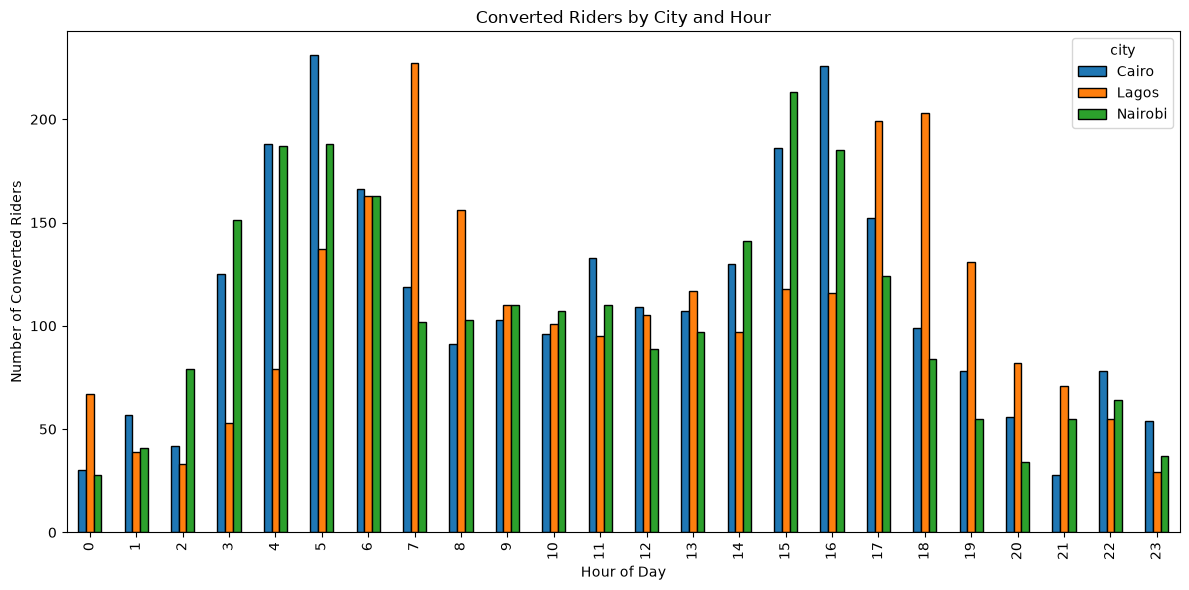

In [67]:
import matplotlib.pyplot as plt

pivot = city_by_hour.pivot(index='hour', columns='city', values='converted_count').fillna(0)

pivot.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Converted Riders by City and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Converted Riders')
plt.tight_layout()
plt.show()

In [75]:
sessions = dfs['sessions'].copy()
sessions['session_time'] = pd.to_datetime(sessions['session_time'], errors='coerce', utc=True)
sessions['hour'] = sessions['session_time'].dt.hour

city_by_hour = (
    sessions[sessions['converted'] == 0]
    .groupby(['hour', 'city'])
    .size()
    .reset_index(name='unconverted_count')
)

unconverted_city_by_hour = city_by_hour.loc[
    city_by_hour.groupby('hour')['unconverted_count'].idxmin()
]

print(unconverted_city_by_hour)

    hour     city  unconverted_count
0      0    Cairo                144
4      1    Lagos                221
7      2    Lagos                155
10     3    Lagos                263
13     4    Lagos                363
16     5    Lagos                718
20     6  Nairobi                800
23     7  Nairobi                606
26     8  Nairobi                527
29     9  Nairobi                557
31    10    Lagos                518
34    11    Lagos                542
36    12    Cairo                513
39    13    Cairo                567
43    14    Lagos                523
46    15    Lagos                603
49    16    Lagos                758
53    17  Nairobi                707
56    18  Nairobi                467
59    19  Nairobi                363
62    20  Nairobi                222
63    21    Cairo                185
67    22    Lagos                274
70    23    Lagos                183


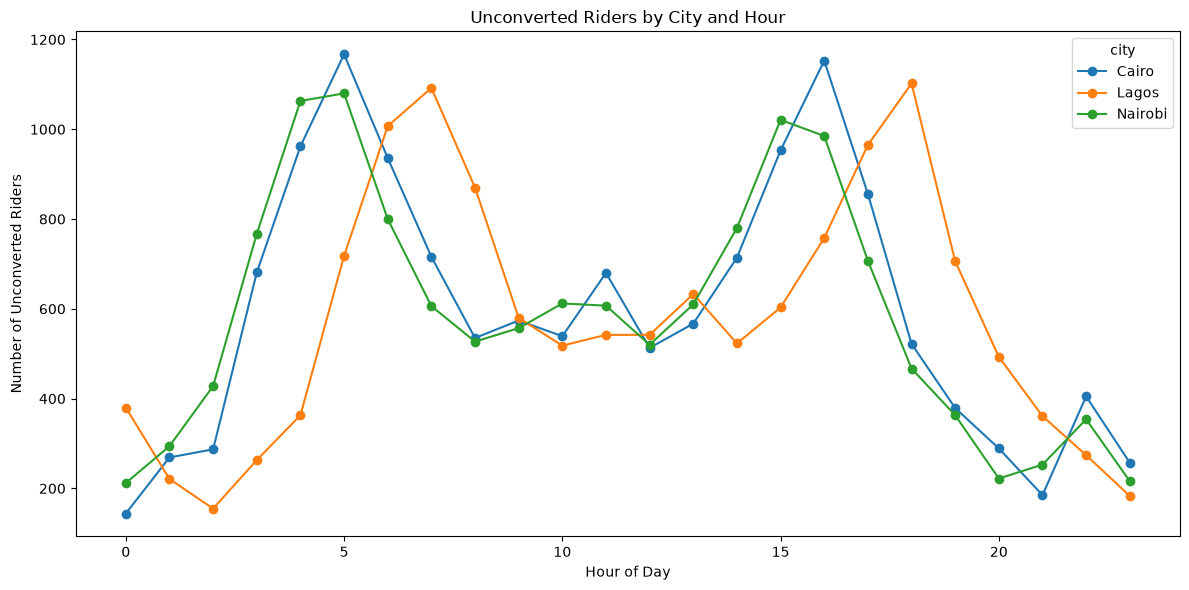

In [77]:
pivot = city_by_hour.pivot(index='hour', columns='city', values='unconverted_count').fillna(0)

pivot.plot(figsize=(12, 6), marker='o')
plt.title('Unconverted Riders by City and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Unconverted Riders')
plt.tight_layout()
plt.show()

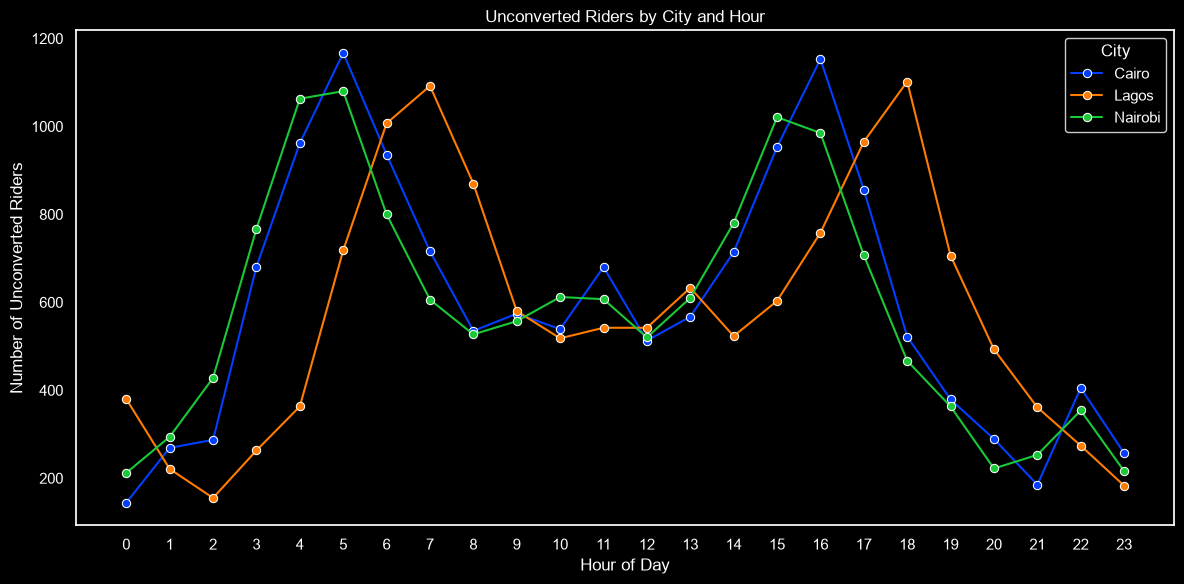

In [91]:
# Apply the dark style ONLY to this chart (rest of notebook stays light)
with plt.style.context('dark_background'):

    plt.figure(figsize=(12, 6))

    # Line per city, bright palette so lines pop on black
    sns.lineplot(
        data=city_by_hour,
        x='hour',
        y='unconverted_count',
        hue='city',
        marker='o',
        palette='bright'
    )

    # Titles and labels (white text reads on black)
    plt.title('Unconverted Riders by City and Hour', color='white')
    plt.xlabel('Hour of Day', color='white')
    plt.ylabel('Number of Unconverted Riders', color='white')
    

    # Show every hour on the x-axis
    plt.xticks(range(0, 24), color='white')
    plt.yticks(color='white')

    # Remove the grid
    plt.grid(False)


    # Style the legend for dark background
    legend = plt.legend(title='City')
    legend.get_frame().set_facecolor('black')
    legend.get_frame().set_edgecolor('white')
    plt.setp(legend.get_texts(), color='white')
    plt.setp(legend.get_title(), color='white')

    plt.tight_layout()
    plt.show()